In [3]:
from google.colab import files
import pandas as pd

print("📂 Hãy upload 6 file Excel: JPM, BAC, WFC, FED, SPX, sentiment")

uploaded = files.upload()

# Tạo biến chứa dataframe
df_jpm = df_bac = df_wfc = df_fed = df_spx = df_sentiment = None

for filename in uploaded.keys():

    print("Đã tải:", filename)

    if "JPM" in filename or "JP Morgan" in filename:
        df_jpm = pd.read_excel(filename)

    elif "BAC" in filename or "Bank of America" in filename:
        df_bac = pd.read_excel(filename)

    elif "WFC" in filename or "Wells Fargo " in filename:
        df_wfc = pd.read_excel(filename)

    elif "Lãi suất FED" in filename:
        df_fed = pd.read_excel(filename)

    elif "SPX500" in filename:
        df_spx = pd.read_excel(filename)

    elif "Sentiment" in filename:
        df_sentiment = pd.read_excel(filename)

# Kiểm tra đủ file chưa
required = {
    "JPM": df_jpm,
    "BAC": df_bac,
    "WFC": df_wfc,
    "FED": df_fed,
    "SPX": df_spx,
    "Sentiment": df_sentiment
}

missing = [name for name, df in required.items() if df is None]

if missing:
    print("\n❌ Thiếu file:", missing)
else:
    print("\n✅ Đã load đủ 6 file!")


📂 Hãy upload 6 file Excel: JPM, BAC, WFC, FED, SPX, sentiment


Saving SPX500.csv.xlsx to SPX500.csv (1).xlsx
Saving Sentiment.xlsx to Sentiment (1).xlsx
Saving JP Morgan.xlsx to JP Morgan (1).xlsx
Saving Lãi suất FED.xlsx to Lãi suất FED (1).xlsx
Saving Wells Fargo.xlsx to Wells Fargo (1).xlsx
Saving Bank of America.xlsx to Bank of America (1).xlsx
Đã tải: SPX500.csv (1).xlsx
Đã tải: Sentiment (1).xlsx
Đã tải: JP Morgan (1).xlsx
Đã tải: Lãi suất FED (1).xlsx
Đã tải: Wells Fargo (1).xlsx
Đã tải: Bank of America (1).xlsx

✅ Đã load đủ 6 file!


In [4]:


print("🟢 BƯỚC 1: ĐANG ĐỌC VÀ LÀM SẠCH DỮ LIỆU THÔ...")

# --- 1. HÀM CHUẨN HÓA NGÀY THÁNG ---
def clean_date(df):
    # Xóa khoảng trắng thừa ở tên cột
    df.columns = df.columns.str.strip()
    # Tìm cột Date
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date']).dt.normalize() # Xóa giờ phút giây
    return df

# --- 2. ĐỌC DỮ LIỆU TỪ FILE ---
try:
    # A. Dữ liệu Vĩ mô & Tin tức
    fed = pd.read_excel('Lãi suất FED (1).xlsx')
    sentiment = pd.read_excel('Sentiment (1).xlsx')
    spx = pd.read_excel('SPX500.csv (1).xlsx')

    # B. Dữ liệu 3 Cổ phiếu
    jpm = pd.read_excel('JP Morgan (1).xlsx')
    wfc = pd.read_excel('Wells Fargo (1).xlsx')
    bac = pd.read_excel('Bank of America (1).xlsx')

    print("   -> Đã đọc xong 6 file Excel.")

except FileNotFoundError:
    print("❌ LỖI: Không tìm thấy file. Hãy đảm bảo bạn đã upload đủ 6 file và đúng tên.")
    # Dừng chương trình nếu thiếu file
    raise

# --- 3. LÀM SẠCH CHI TIẾT ---

# A. Chuẩn hóa ngày tháng cho tất cả
fed = clean_date(fed)
sentiment = clean_date(sentiment)
spx = clean_date(spx)
jpm = clean_date(jpm)
wfc = clean_date(wfc)
bac = clean_date(bac)

# B. Xử lý file Lãi suất FED (Thường hay bị lỗi định dạng text)
# Ép cột EFFR sang số, nếu lỗi biến thành NaN
fed['EFFR'] = pd.to_numeric(fed['EFFR'], errors='coerce')
# Sắp xếp theo ngày
fed = fed.sort_values('Date')
# Lấp đầy lãi suất (Forward Fill - Lãi suất hôm nay = hôm qua nếu ko có dữ liệu)
fed['EFFR'] = fed['EFFR'].ffill()

# C. Đổi tên cột để tránh trùng lặp khi gộp
# Chỉ giữ lại cột Date, Close và Volume (nếu cần)
spx = spx[['Date', 'Close']].rename(columns={'Close': 'SPX_Close'})

jpm = jpm[['Date', 'Close']].rename(columns={'Close': 'JPM_Close'})
wfc = wfc[['Date', 'Close']].rename(columns={'Close': 'WFC_Close'})
bac = bac[['Date', 'Close']].rename(columns={'Close': 'BAC_Close'})

# --- 4. HỢP NHẤT DỮ LIỆU (MERGE) ---
print("🟡 BƯỚC 2: ĐANG GỘP DỮ LIỆU (MERGE)...")

# Lấy SPX làm khung xương (Backbone) vì chỉ số thị trường có lịch giao dịch chuẩn nhất
master_df = spx

# Gộp lần lượt các cổ phiếu vào (Left Join theo ngày)
master_df = master_df.merge(jpm, on='Date', how='left')
master_df = master_df.merge(wfc, on='Date', how='left')
master_df = master_df.merge(bac, on='Date', how='left')

# Gộp thông tin vĩ mô (FED) và Tin tức (Sentiment)
master_df = master_df.merge(fed[['Date', 'EFFR']], on='Date', how='left')
master_df = master_df.merge(sentiment, on='Date', how='left')

# --- 5. XỬ LÝ SAU KHI GỘP ---
# A. Lấp đầy dữ liệu FED cho những ngày cuối tuần/nghỉ lễ nếu bị hổng
master_df['EFFR'] = master_df['EFFR'].ffill()

# B. Xử lý Sentiment bị thiếu (NaN -> 0)
# Tìm các cột sentiment tự động
sent_cols = [c for c in master_df.columns if 'sentiment' in c or 'news_count' in c]
master_df[sent_cols] = master_df[sent_cols].fillna(0)

# C. Loại bỏ những ngày không giao dịch (Cả 3 cổ phiếu đều NaN)
stock_cols = ['JPM_Close', 'WFC_Close', 'BAC_Close']
master_df = master_df.dropna(subset=stock_cols, how='all').reset_index(drop=True)

# Kiểm tra kết quả
print(f"✅ HOÀN TẤT! Master DataFrame có kích thước: {master_df.shape}")
print("   -> Sẵn sàng cho bước dự báo.")
print("-" * 60)
print(master_df.head())

🟢 BƯỚC 1: ĐANG ĐỌC VÀ LÀM SẠCH DỮ LIỆU THÔ...
   -> Đã đọc xong 6 file Excel.
🟡 BƯỚC 2: ĐANG GỘP DỮ LIỆU (MERGE)...
✅ HOÀN TẤT! Master DataFrame có kích thước: (1977, 12)
   -> Sẵn sàng cho bước dự báo.
------------------------------------------------------------
        Date    SPX_Close  JPM_Close  WFC_Close  BAC_Close  EFFR  \
0 2018-01-02  2695.810059     107.95      61.09      29.90  1.42   
1 2018-01-03  2713.060059     108.06      61.56      29.80  1.42   
2 2018-01-04  2723.989990     109.04      62.33      30.19  1.42   
3 2018-01-05  2743.149902     108.34      62.75      30.33  1.42   
4 2018-01-08  2747.709961     108.50      62.04      30.12  1.91   

   BAC_news_count  JPM_news_count  WFC_news_count  BAC_avg_sentiment  \
0             0.0             0.0             0.0                0.0   
1             0.0             0.0             0.0                0.0   
2             0.0             0.0             0.0                0.0   
3             0.0             0.0      

In [5]:
import pandas as pd

def merge_stock(df_stock, df_fed, df_spx, df_sentiment, ticker):
    # Tạo bản sao
    df_stock = df_stock.copy()
    df_fed = df_fed.copy()
    df_spx = df_spx.copy()
    df_sentiment = df_sentiment.copy()

    # --- SỬA LỖI QUAN TRỌNG: CẮT BỎ GIỜ PHÚT ---
    # .dt.normalize() sẽ đưa 16:00:00 về 00:00:00 để khớp với các file kia
    df_stock['Date'] = pd.to_datetime(df_stock['Date']).dt.normalize()
    df_fed['Date'] = pd.to_datetime(df_fed['Date']).dt.normalize()
    df_spx['Date'] = pd.to_datetime(df_spx['Date']).dt.normalize()
    df_sentiment['Date'] = pd.to_datetime(df_sentiment['Date']).dt.normalize()
    # -------------------------------------------

    # Đổi tên cột Close của SPX để tránh trùng
    if 'Close' in df_spx.columns:
        df_spx = df_spx.rename(columns={'Close': 'SPX_Close'})

    # Chỉ lấy cột Date và Close của SPX để bảng gọn gàng hơn, tránh dư cột _x, _y
    df_spx_clean = df_spx[['Date', 'SPX_Close']] if 'SPX_Close' in df_spx.columns else df_spx

    # Merge lần lượt (Left Join)
    df_merge = df_stock.merge(df_fed, on='Date', how='left')
    df_merge = df_merge.merge(df_spx_clean, on='Date', how='left')

    # Xử lý Sentiment
    sent_col = f'{ticker}_avg_sentiment'
    if sent_col in df_sentiment.columns:
        df_merge = df_merge.merge(df_sentiment[['Date', sent_col]], on='Date', how='left')
    else:
        print(f"⚠️ Không tìm thấy cột sentiment cho {ticker}, tự động điền 0.")
        df_merge[sent_col] = 0

    # Fill NaN (Lấp đầy dữ liệu trống)
    for col in df_merge.columns:
        if col != 'Date':
            df_merge[col] = pd.to_numeric(df_merge[col], errors='coerce')
            df_merge[col] = df_merge[col].ffill().bfill() # Lấp xuôi rồi lấp ngược

            # Nếu vẫn còn NaN (do file ngoại sinh thiếu dữ liệu đầu/cuối), điền 0 hoặc giá trị trung bình
            df_merge[col] = df_merge[col].fillna(0)

    # Sắp xếp theo ngày
    df_merge = df_merge.sort_values('Date').reset_index(drop=True)

    return df_merge

# --- CHẠY LẠI ---
print("⏳ Đang thực hiện Merge lại (đã xử lý giờ phút)...")
df_jpm_merge = merge_stock(df_jpm, df_fed, df_spx, df_sentiment, 'JPM')
df_bac_merge = merge_stock(df_bac, df_fed, df_spx, df_sentiment, 'BAC')
df_wfc_merge = merge_stock(df_wfc, df_fed, df_spx, df_sentiment, 'WFC')

# --- KIỂM TRA KỸ ---
print("\n✅ Dữ liệu JPM sau khi sửa:")
print(df_jpm_merge[['Date', 'Close', 'EFFR', 'SPX_Close', 'JPM_avg_sentiment']].head())

# Kiểm tra xem còn NaN không
nan_count = df_jpm_merge['EFFR'].isna().sum()
print(f"\nSố lượng dòng bị lỗi NaN trong cột Lãi suất (EFFR): {nan_count}")
if nan_count == 0:
    print("🎉 Dữ liệu đã sạch 100%! Bạn có thể chạy mô hình Expanding Window ngay.")
else:
    print("⚠️ Vẫn còn lỗi NaN, hãy kiểm tra lại file Lãi suất.")

⏳ Đang thực hiện Merge lại (đã xử lý giờ phút)...

✅ Dữ liệu JPM sau khi sửa:
        Date   Close  EFFR    SPX_Close  JPM_avg_sentiment
0 2018-01-02  107.95  1.42  2695.810059                0.0
1 2018-01-03  108.06  1.42  2713.060059                0.0
2 2018-01-04  109.04  1.42  2723.989990                0.0
3 2018-01-05  108.34  1.42  2743.149902                0.0
4 2018-01-08  108.50  1.91  2747.709961                0.0

Số lượng dòng bị lỗi NaN trong cột Lãi suất (EFFR): 0
🎉 Dữ liệu đã sạch 100%! Bạn có thể chạy mô hình Expanding Window ngay.


📉 Đang tính toán sai số (RMSE, MAPE) cho JPM bằng mô hình Tự xây...
🔮 --- ĐANG DỰ BÁO 90 NGÀY TƯƠNG LAI CHO JPM (MÔ HÌNH TỰ XÂY) ---
   -> Đang tính toán đệ quy (Recursive)...


100%|██████████| 90/90 [00:00<00:00, 9876.96it/s]

🎨 Đang vẽ biểu đồ...


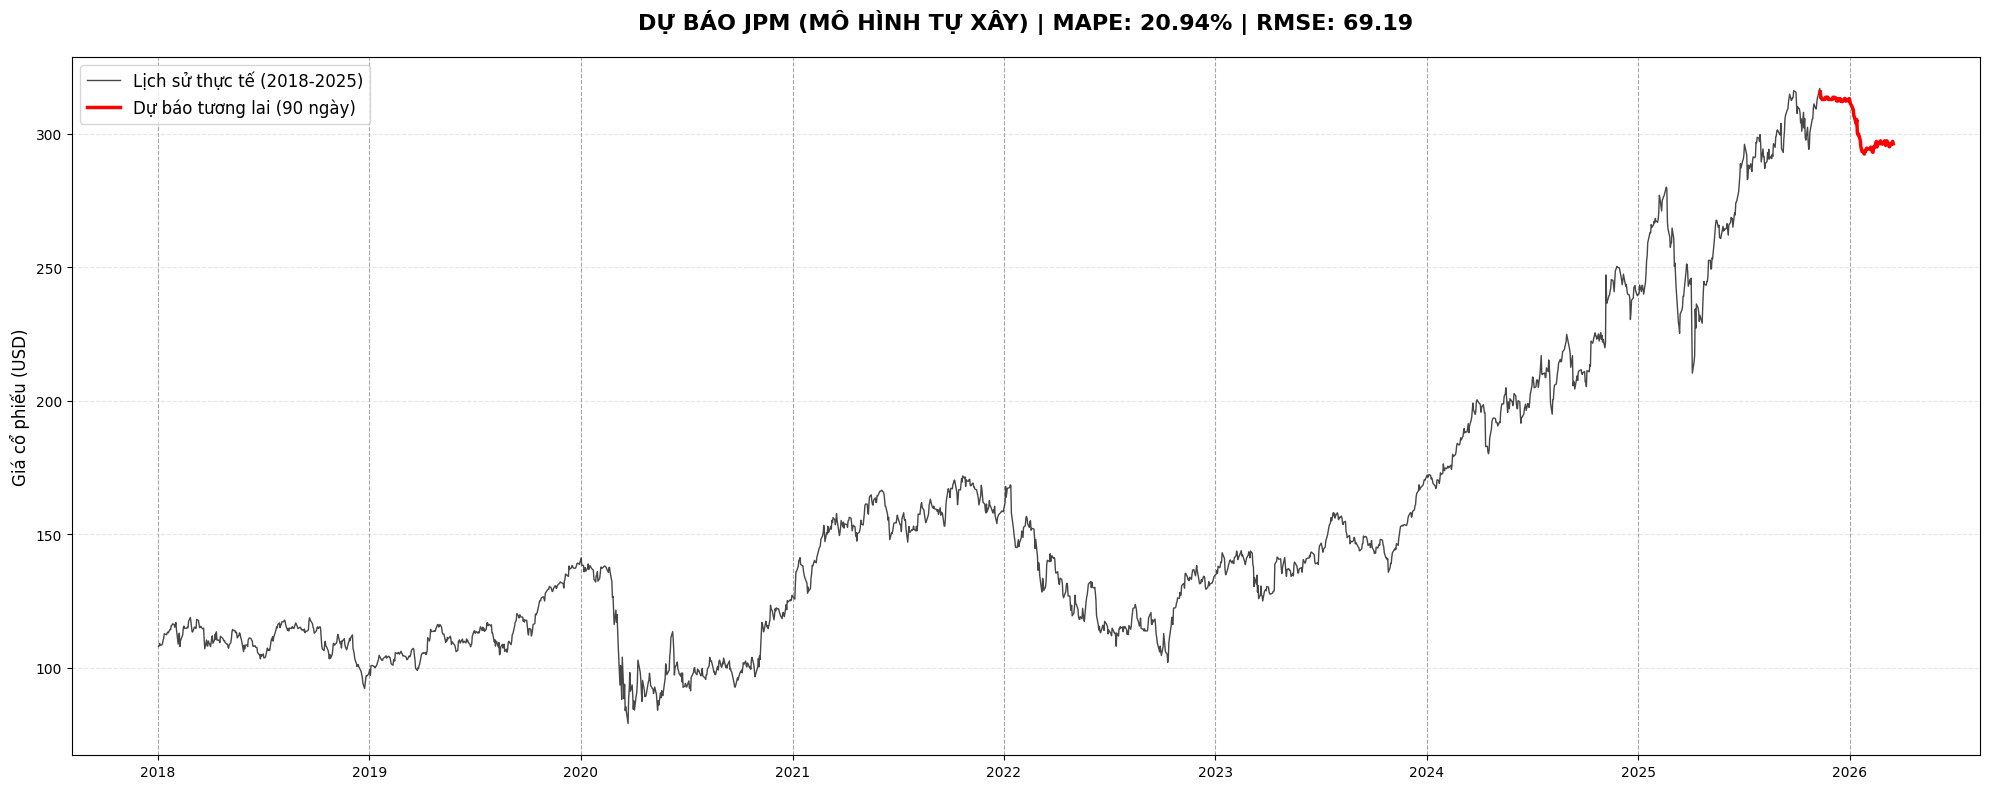

📉 Đang tính toán sai số (RMSE, MAPE) cho BAC bằng mô hình Tự xây...
🔮 --- ĐANG DỰ BÁO 90 NGÀY TƯƠNG LAI CHO BAC (MÔ HÌNH TỰ XÂY) ---
   -> Đang tính toán đệ quy (Recursive)...


100%|██████████| 90/90 [00:00<00:00, 4593.09it/s]

🎨 Đang vẽ biểu đồ...


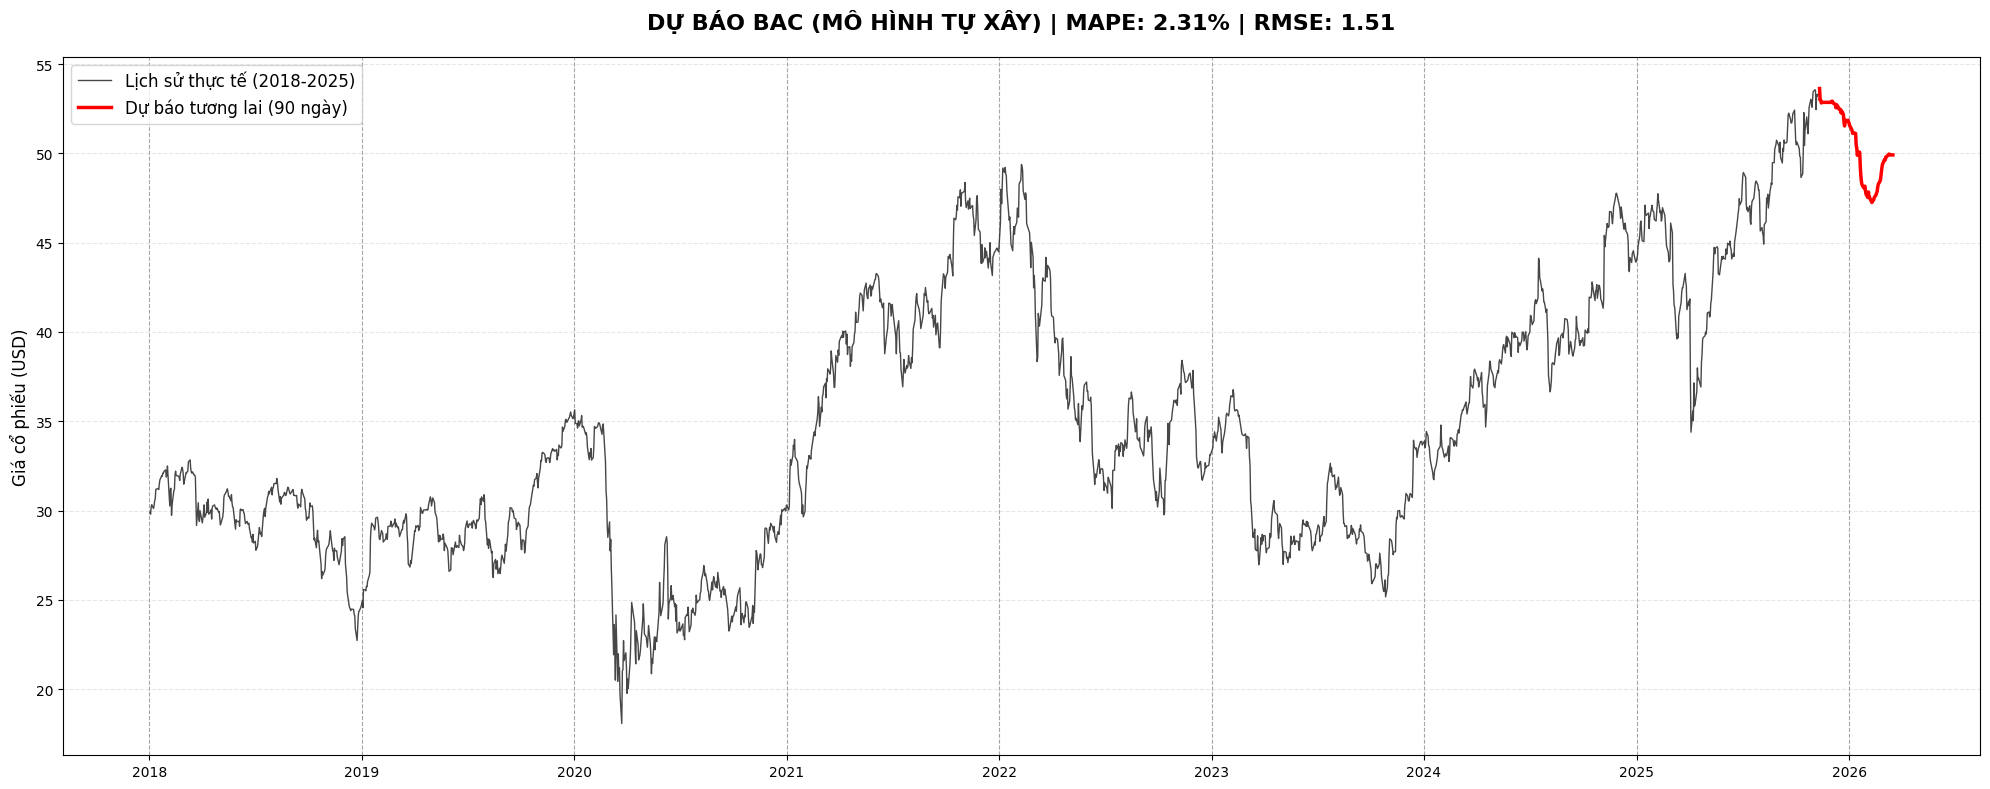

📉 Đang tính toán sai số (RMSE, MAPE) cho WFC bằng mô hình Tự xây...
🔮 --- ĐANG DỰ BÁO 90 NGÀY TƯƠNG LAI CHO WFC (MÔ HÌNH TỰ XÂY) ---
   -> Đang tính toán đệ quy (Recursive)...


100%|██████████| 90/90 [00:00<00:00, 4574.61it/s]

🎨 Đang vẽ biểu đồ...


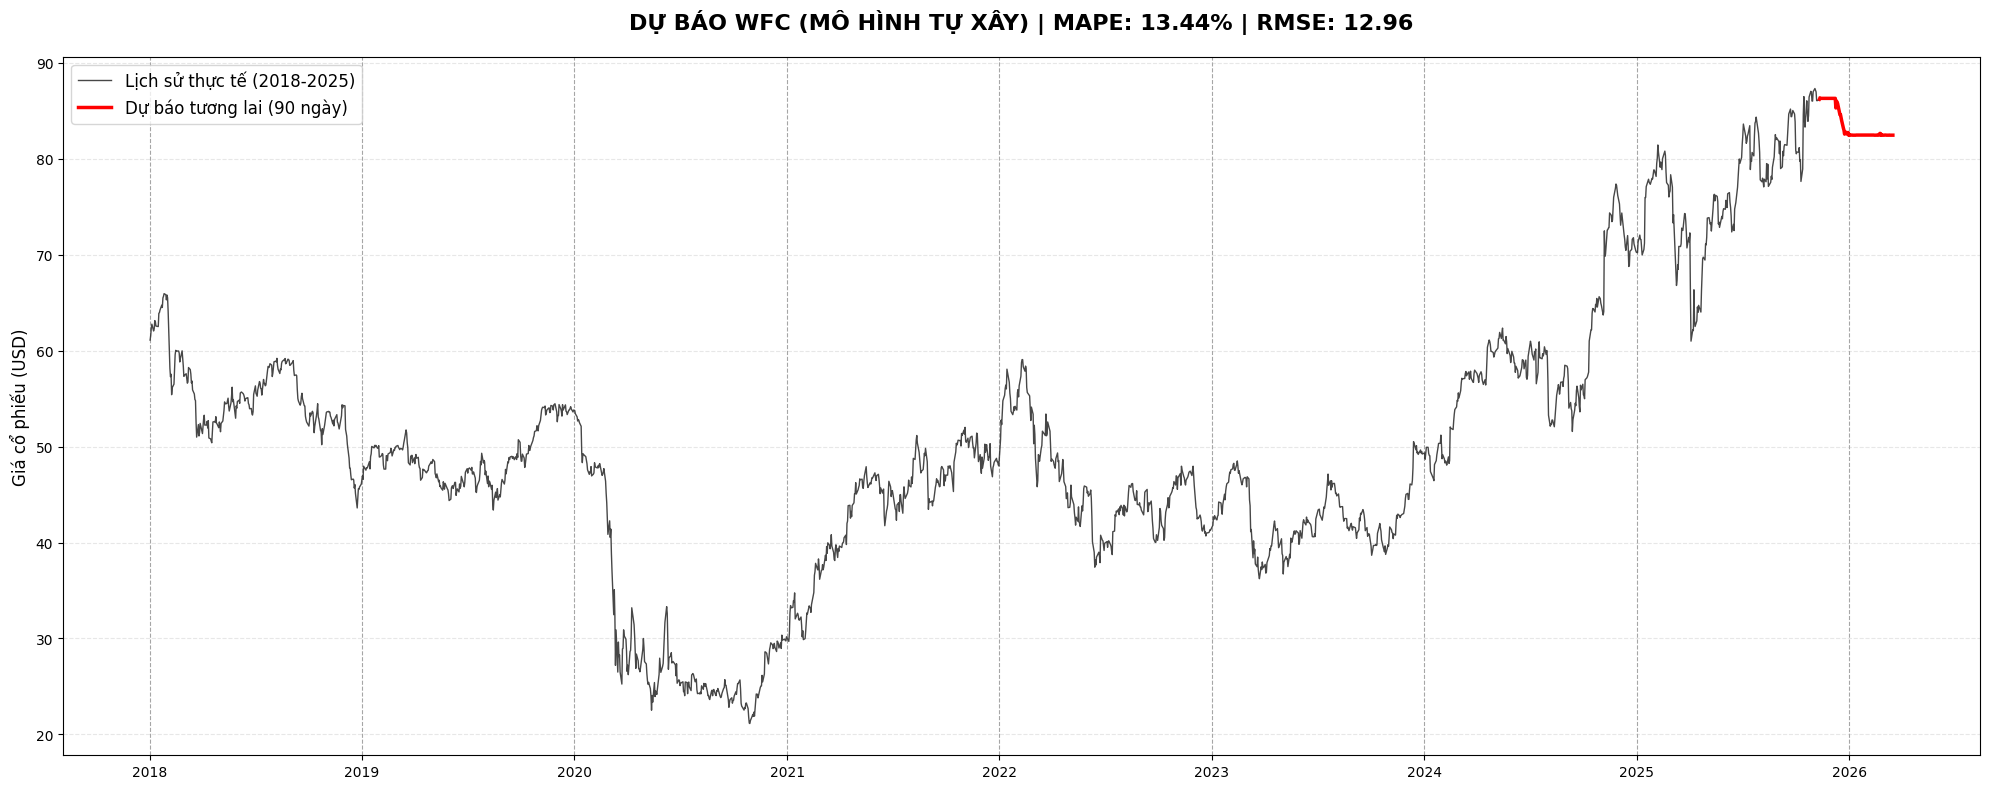

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ==============================================================================
# PHẦN 1: TỰ XÂY DỰNG RANDOM FOREST (BUILD FROM SCRATCH)
# ==============================================================================

class Node:
    def __init__(self, feature_idx=None, threshold=None, left=None, right=None, value=None):
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # Giá trị dự báo (nếu là lá)

class MyDecisionTree:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        self.root = self._build_tree(X, y)

    def _build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        # Điều kiện dừng: Đạt độ sâu tối đa hoặc ít mẫu quá
        if depth >= self.max_depth or n_samples < self.min_samples_split:
            return Node(value=np.mean(y))

        # Tìm điểm cắt tốt nhất
        best_feat, best_thresh = self._best_split(X, y, n_features)

        if best_feat is None:
            return Node(value=np.mean(y))

        # Chia dữ liệu
        left_idxs = X[:, best_feat] < best_thresh
        right_idxs = ~left_idxs

        left_child = self._build_tree(X[left_idxs], y[left_idxs], depth + 1)
        right_child = self._build_tree(X[right_idxs], y[right_idxs], depth + 1)

        return Node(feature_idx=best_feat, threshold=best_thresh, left=left_child, right=right_child)

    def _best_split(self, X, y, n_features):
        best_var_red = -1
        split_idx, split_thresh = None, None

        # Chọn ngẫu nhiên một số features để tăng tính ngẫu nhiên (đặc trưng của RF)
        feat_idxs = np.random.choice(n_features, size=int(np.sqrt(n_features)), replace=False)

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            # Giảm số lượng threshold để chạy nhanh hơn (lấy mẫu)
            if len(thresholds) > 10:
                thresholds = np.random.choice(thresholds, size=10, replace=False)

            for thr in thresholds:
                left_idxs = X_column < thr
                if np.sum(left_idxs) == 0 or np.sum(~left_idxs) == 0:
                    continue

                # Tính Variance Reduction
                curr_var_red = self._variance_reduction(y, y[left_idxs], y[~left_idxs])

                if curr_var_red > best_var_red:
                    best_var_red = curr_var_red
                    split_idx = feat_idx
                    split_thresh = thr

        return split_idx, split_thresh

    def _variance_reduction(self, parent, l_child, r_child):
        weight_l = len(l_child) / len(parent)
        weight_r = len(r_child) / len(parent)
        return np.var(parent) - (weight_l * np.var(l_child) + weight_r * np.var(r_child))

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature_idx] < node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

class MyRandomForestRegressor:
    def __init__(self, n_estimators=10, max_depth=5, min_samples_split=2):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_estimators):
            # Bootstrap sampling (Lấy mẫu có hoàn lại)
            idxs = np.random.choice(len(X), size=len(X), replace=True)
            X_sample, y_sample = X[idxs], y[idxs]

            tree = MyDecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        # Lấy trung bình cộng các cây (Regression)
        return np.mean(tree_preds, axis=0)

# ==============================================================================
# PHẦN 2: HÀM TÍNH TOÁN MAPE & RMSE (BACKTEST)
# ==============================================================================
def calculate_metrics(df, ticker):
    print(f"📉 Đang tính toán sai số (RMSE, MAPE) cho {ticker} bằng mô hình Tự xây...")

    data = df.copy()
    target_col = 'Close'
    exog_cols = ['EFFR', 'SPX_Close', f'{ticker}_avg_sentiment']

    # Tạo Lag
    lags = 3
    lag_cols = []
    for i in range(1, lags + 1):
        col_name = f'Lag_{i}'
        data[col_name] = data[target_col].shift(i)
        lag_cols.append(col_name)
    data = data.dropna().reset_index(drop=True)

    features = exog_cols + lag_cols

    # Chia Train/Test (Lấy 20% cuối làm test để tính sai số)
    test_size = int(len(data) * 0.2)
    train_data = data.iloc[:-test_size]
    test_data = data.iloc[-test_size:]

    X_train = train_data[features].values
    y_train = train_data[target_col].values
    X_test = test_data[features].values
    y_test = test_data[target_col].values

    # --- DÙNG MÔ HÌNH TỰ XÂY ---
    # Giảm nhẹ tham số để chạy nhanh (n_estimators=10, max_depth=5)
    rf_custom = MyRandomForestRegressor(n_estimators=10, max_depth=5)
    rf_custom.fit(X_train, y_train)

    preds = rf_custom.predict(X_test)

    # Tính metrics
    rmse = np.sqrt(np.mean((y_test - preds) ** 2))
    mape = np.mean(np.abs((y_test - preds) / y_test))

    return rmse, mape

# ==============================================================================
# PHẦN 3: DỰ BÁO TƯƠNG LAI & VẼ BIỂU ĐỒ
# ==============================================================================
def run_full_analysis_custom(df, ticker):
    # 1. Tính toán sai số trước
    rmse_score, mape_score = calculate_metrics(df, ticker)

    print(f"🔮 --- ĐANG DỰ BÁO 90 NGÀY TƯƠNG LAI CHO {ticker} (MÔ HÌNH TỰ XÂY) ---")

    # Chuẩn bị dữ liệu full
    data = df.copy()
    target_col = 'Close'
    exog_cols = ['EFFR', 'SPX_Close', f'{ticker}_avg_sentiment']

    lags = 3
    lag_cols = []
    for i in range(1, lags + 1):
        col_name = f'Lag_{i}'
        data[col_name] = data[target_col].shift(i)
        lag_cols.append(col_name)
    data = data.dropna().reset_index(drop=True)
    features = exog_cols + lag_cols

    # Chuyển sang numpy array cho mô hình tự xây
    X_full = data[features].values
    y_full = data[target_col].values

    # Huấn luyện trên toàn bộ lịch sử
    # Tăng nhẹ tham số lên một chút cho bản final (n=15)
    rf = MyRandomForestRegressor(n_estimators=15, max_depth=6)
    rf.fit(X_full, y_full)

    # Tạo kịch bản tương lai
    days_predict = 90
    last_date = data['Date'].iloc[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=days_predict, freq='B')

    last_effr = data['EFFR'].iloc[-1]
    last_spx = data['SPX_Close'].iloc[-1]

    future_spx = []
    current_spx = last_spx
    np.random.seed(42)
    for _ in range(days_predict):
        shock = np.random.normal(loc=0.0003, scale=0.008)
        current_spx = current_spx * (1 + shock)
        future_spx.append(current_spx)

    future_effr = [last_effr] * days_predict
    future_sentiment = np.random.normal(0, 0.1, days_predict)

    # Dự báo đệ quy
    future_prices = []
    current_lag_1 = data[target_col].iloc[-1]
    current_lag_2 = data[target_col].iloc[-2]
    current_lag_3 = data[target_col].iloc[-3]

    print("   -> Đang tính toán đệ quy (Recursive)...")
    for i in tqdm(range(days_predict)):
        input_row = np.array([[
            future_effr[i], future_spx[i], future_sentiment[i],
            current_lag_1, current_lag_2, current_lag_3
        ]])

        pred = rf.predict(input_row)[0]
        future_prices.append(pred)

        current_lag_3 = current_lag_2
        current_lag_2 = current_lag_1
        current_lag_1 = pred

    df_forecast = pd.DataFrame({'Date': future_dates, 'Forecast': future_prices})

    # ==========================================
    # VẼ BIỂU ĐỒ (ĐÃ CHỈNH SỬA THEO YÊU CẦU)
    # ==========================================
    print(f"🎨 Đang vẽ biểu đồ...")
    fig, ax = plt.subplots(figsize=(20, 8))

    # A. Vẽ Lịch sử
    start_year = df['Date'].dt.year.min()
    end_year = df['Date'].dt.year.max()
    ax.plot(df['Date'], df['Close'],
            label=f'Lịch sử thực tế ({start_year}-{end_year})',
            color='#333333', linewidth=1, alpha=0.9)

    # B. Vẽ Dự báo
    ax.plot(df_forecast['Date'], df_forecast['Forecast'],
            label='Dự báo tương lai (90 ngày)', color='#ff0000', linewidth=2.5)

    # C. Nối nét
    last_hist_date = df['Date'].iloc[-1]
    last_hist_price = df['Close'].iloc[-1]
    first_pred_date = df_forecast['Date'].iloc[0]
    first_pred_price = df_forecast['Forecast'].iloc[0]
    ax.plot([last_hist_date, first_pred_date], [last_hist_price, first_pred_price],
            color='#ff0000', linestyle='-', linewidth=2.5)

    # D. Định dạng trục
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True, which='major', axis='x', linestyle='--', alpha=0.7, color='gray')
    ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.3)

    # E. Tiêu đề chứa Metrics (RMSE, MAPE)
    ax.set_title(f'DỰ BÁO {ticker} (MÔ HÌNH TỰ XÂY) | MAPE: {mape_score:.2%} | RMSE: {rmse_score:.2f}',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel('Giá cổ phiếu (USD)', fontsize=12)

    # Đã xóa phần ax.annotate hiển thị số

    ax.legend(loc='upper left', fontsize=12)
    plt.tight_layout()
    plt.show()

# ==========================================
# CHẠY CHƯƠNG TRÌNH
# ==========================================

# 1. JPM
if 'df_jpm_merge' in globals():
    run_full_analysis_custom(df_jpm_merge, 'JPM')

# 2. BAC
if 'df_bac_merge' in globals():
    run_full_analysis_custom(df_bac_merge, 'BAC')

# 3. WFC
if 'df_wfc_merge' in globals():
    run_full_analysis_custom(df_wfc_merge, 'WFC')

In [7]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

# =====================================================
# NODE CỦA CÂY QUYẾT ĐỊNH
# =====================================================
class Node:
    def __init__(self, feature_idx=None, threshold=None,
                 left=None, right=None, value=None):
        self.feature_idx = feature_idx   # cột được chọn để split
        self.threshold = threshold       # ngưỡng split
        self.left = left                 # node trái
        self.right = right               # node phải
        self.value = value               # giá trị nếu là lá (leaf)

# =====================================================
# CÂY QUYẾT ĐỊNH TỰ XÂY
# =====================================================
class MyDecisionTree:
    def __init__(self, max_depth=6, min_samples_split=3):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    # Hàm huấn luyện
    def fit(self, X, y):
        self.root = self._build_tree(X, y)

    # Hàm xây cây
    def _build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape

        # Điều kiện dừng
        if depth >= self.max_depth or n_samples < self.min_samples_split:
            leaf_value = np.mean(y)
            return Node(value=leaf_value)

        # Tìm split tốt nhất
        best_feat, best_thresh = self._best_split(X, y, n_features)

        if best_feat is None:
            return Node(value=np.mean(y))

        # Tách nhánh trái – phải
        left_idxs = X[:, best_feat] < best_thresh
        right_idxs = ~left_idxs

        left_child = self._build_tree(X[left_idxs], y[left_idxs], depth+1)
        right_child = self._build_tree(X[right_idxs], y[right_idxs], depth+1)

        return Node(feature_idx=best_feat, threshold=best_thresh,
                    left=left_child, right=right_child)

    # Tìm điểm split tốt nhất
    def _best_split(self, X, y, n_features):
        best_var_red = -1
        split_idx, split_thresh = None, None

        # Feature sampling: sqrt(n_features)
        feat_idxs = np.random.choice(n_features, int(np.sqrt(n_features)), replace=False)

        for feat in feat_idxs:
            X_col = X[:, feat]
            thresholds = np.unique(X_col)

            # sampling ngưỡng để tiết kiệm thời gian
            if len(thresholds) > 12:
                thresholds = np.random.choice(thresholds, 12, replace=False)

            for t in thresholds:
                left = X_col < t
                right = ~left

                if left.sum() == 0 or right.sum() == 0:
                    continue

                var_red = self._variance_reduction(y, y[left], y[right])
                if var_red > best_var_red:
                    best_var_red = var_red
                    split_idx = feat
                    split_thresh = t

        return split_idx, split_thresh

    # Variance reduction
    def _variance_reduction(self, parent, left, right):
        w_l = len(left) / len(parent)
        w_r = len(right) / len(parent)
        return np.var(parent) - (w_l * np.var(left) + w_r * np.var(right))

    # Dự báo cho một vector
    def _traverse(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature_idx] < node.threshold:
            return self._traverse(x, node.left)
        else:
            return self._traverse(x, node.right)

    # Dự báo cho nhiều mẫu
    def predict(self, X):
        return np.array([self._traverse(row, self.root) for row in X])


# =====================================================
# RANDOM FOREST TỰ XÂY
# =====================================================
class MyRandomForestRegressor:
    def __init__(self, n_estimators=15, max_depth=6, min_samples_split=3):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    # Huấn luyện
    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_estimators):
            # Bootstrap sampling
            idxs = np.random.choice(len(X), len(X), replace=True)
            X_sample = X[idxs]
            y_sample = y[idxs]

            tree = MyDecisionTree(max_depth=self.max_depth,
                                  min_samples_split=self.min_samples_split)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    # Dự báo
    def predict(self, X):
        preds = np.array([tree.predict(X) for tree in self.trees])
        return np.mean(preds, axis=0)


In [8]:
def backtest_walk_forward(df, ticker, train_size=400):
    data = df.copy().dropna().reset_index(drop=True)

    target = "Close"
    exog = ["EFFR", "SPX_Close", f"{ticker}_avg_sentiment"]

    # tạo lag
    for i in range(1, 4):
        data[f"Lag_{i}"] = data[target].shift(i)

    data = data.dropna().reset_index(drop=True)
    features = exog + [f"Lag_{i}" for i in range(1, 4)]

    X = data[features].values
    y = data[target].values
    dates = data["Date"].values

    preds, actuals, pred_dates = [], [], []

    print(f"\n🚀 WALK-FORWARD BACKTEST cho {ticker}")

    for t in tqdm(range(train_size, len(X))):
        X_train = X[:t]
        y_train = y[:t]

        model = MyRandomForestRegressor(n_estimators=12, max_depth=6)
        model.fit(X_train, y_train)

        pred = model.predict(X[t].reshape(1, -1))[0]

        preds.append(pred)
        actuals.append(y[t])
        pred_dates.append(dates[t])

    rmse = np.sqrt(np.mean((np.array(actuals) - np.array(preds))**2))
    mape = np.mean(np.abs((np.array(actuals) - np.array(preds)) / np.array(actuals)))

    print(f"   -> RMSE={rmse:.2f} | MAPE={mape:.2%}")

    return rmse, mape, pred_dates, preds, actuals


In [9]:
def forecast_90days(df, ticker):
    data = df.copy().dropna().reset_index(drop=True)

    target = "Close"
    exog = ["EFFR", "SPX_Close", f"{ticker}_avg_sentiment"]

    # lag
    for i in range(1, 4):
        data[f"Lag_{i}"] = data[target].shift(i)
    data = data.dropna().reset_index(drop=True)

    features = exog + [f"Lag_{i}" for i in range(1, 4)]

    X = data[features].values
    y = data[target].values

    model = MyRandomForestRegressor(n_estimators=15, max_depth=6)
    model.fit(X, y)

    # tạo dữ liệu tương lai
    days = 90
    last_date = data["Date"].iloc[-1]
    dates_future = pd.date_range(start=last_date + pd.Timedelta(days=1),
                                 periods=days, freq="B")

    last_effr = data["EFFR"].iloc[-1]
    last_spx = data["SPX_Close"].iloc[-1]
    future_spx = last_spx * np.cumprod(1 + np.random.normal(0.0004, 0.007, days))

    future_effr = [last_effr] * days
    future_sent = np.random.normal(0, 0.1, days)

    lag1 = data[target].iloc[-1]
    lag2 = data[target].iloc[-2]
    lag3 = data[target].iloc[-3]

    preds = []

    for i in range(days):
        row = np.array([
            future_effr[i],
            future_spx[i],
            future_sent[i],
            lag1, lag2, lag3
        ]).reshape(1, -1)

        pred = model.predict(row)[0]
        preds.append(pred)

        lag3, lag2, lag1 = lag2, lag1, pred

    return pd.DataFrame({"Date": dates_future, "Forecast": preds})


In [ ]:
print("\n================= JPM =================")
rmse_jpm, mape_jpm, _, _, _ = backtest_walk_forward(df_jpm_merge, "JPM")
fc_jpm = forecast_90days(df_jpm_merge, "JPM")

print("\n================= BAC =================")
rmse_bac, mape_bac, _, _, _ = backtest_walk_forward(df_bac_merge, "BAC")
fc_bac = forecast_90days(df_bac_merge, "BAC")

print("\n================= WFC =================")
rmse_wfc, mape_wfc, _, _, _ = backtest_walk_forward(df_wfc_merge, "WFC")
fc_wfc = forecast_90days(df_wfc_merge, "WFC")



================= JPM =================

🚀 WALK-FORWARD BACKTEST cho JPM


100%|██████████| 1574/1574 [25:36<00:00,  1.02it/s]


   -> RMSE=3.68 | MAPE=1.67%

================= BAC =================

🚀 WALK-FORWARD BACKTEST cho BAC


100%|██████████| 1574/1574 [25:48<00:00,  1.02it/s]


   -> RMSE=0.85 | MAPE=1.79%

================= WFC =================

🚀 WALK-FORWARD BACKTEST cho WFC


100%|██████████| 1572/1572 [24:53<00:00,  1.05it/s]


   -> RMSE=1.37 | MAPE=2.13%
